In [1]:
import os
import pandas as pd
from glob import glob
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
from sklearn.linear_model import HuberRegressor

In [2]:
data_dir = '../data/calibration/point_ensemble_ch4/'
enmap_files = glob(os.path.join(data_dir, "*EnMAP*all.csv"))
emit_files = glob(os.path.join(data_dir, "*EMIT*all.csv"))
prisma_files = glob(os.path.join(data_dir, "*PRISMA*all.csv"))


In [3]:
def estimate(df_enmap, df_emit, df_prisma):
    df_enmap['q_csf'] = df_enmap['C'] * (1.15*df_enmap['u10_geo_csf'])*3600
    df_emit['q_csf'] = df_emit['C'] * (1.12*df_emit['u10_geo_csf'])*3600
    df_prisma['q_csf'] = df_prisma['C'] * (1.12*df_prisma['u10_geo_csf'])*3600

    df_enmap['q_ime'] = df_enmap['ime'] * (0.33*df_enmap['u10_ime']+0.44)*3600 / df_enmap['l_eff']
    df_emit['q_ime'] = df_emit['ime'] * (0.36*df_emit['u10_ime']+0.43)*3600 / df_emit['l_eff']
    df_prisma['q_ime'] = df_prisma['ime'] * (0.32*df_prisma['u10_ime']+0.43)*3600 / df_prisma['l_eff']

In [4]:
df_enmap = pd.concat((pd.read_csv(f) for f in enmap_files), ignore_index=True)
df_emit = pd.concat((pd.read_csv(f) for f in emit_files), ignore_index=True)
df_prisma = pd.concat((pd.read_csv(f) for f in prisma_files), ignore_index=True)

df_enmap = df_enmap[df_enmap['C'].notnull()]
df_emit = df_emit[df_emit['C'].notnull()]
df_prisma = df_prisma[df_prisma['C'].notnull()]

estimate(df_enmap, df_emit, df_prisma)

df_enmap_low = df_enmap[df_enmap['emission_rate'] < 2]
df_emit_low = df_emit[df_emit['emission_rate'] < 2]
df_prisma_low = df_prisma[df_prisma['emission_rate'] < 2]

In [5]:
df_enmap

,time,ime,u10_ime,ueff_ime,ugeo_ime,l_eff,leff_ime_crop,lgeo_ime_crop,q_full_ime,C,u10_geo_csf,u10_eff_csf,ueff_csf,l_geo,emission_rate,name,q_csf,q_ime
0,01:00:30,3101.592294,3.978377,1.837268,8.667704,942.496684,NaN,NaN,47.131717,1.159884,4.005394,3.956274,5.212700,4446.430418,21.766059,oakland,19233.581555,20766.134509
1,01:01:00,1923.833857,3.969836,1.769847,5.134048,754.188305,NaN,NaN,36.455485,0.996162,3.973045,3.951323,4.532038,2187.781325,16.252722,oakland,16385.279336,16070.882950
2,01:01:30,38.395215,3.946162,1.690082,6.396770,224.499443,NaN,NaN,2.429625,0.098475,3.955063,3.941998,2.935236,849.705301,1.040572,oakland,1612.427687,1072.681165
3,01:02:00,1637.610612,3.964768,1.764329,9.711356,835.703297,NaN,NaN,27.969122,0.656405,3.994190,3.945097,5.267032,4599.943121,12.446308,oakland,10854.283752,12333.753121
4,01:02:30,2393.941605,3.966250,1.756052,9.037219,990.908674,NaN,NaN,34.495505,0.649902,3.982131,3.942060,6.527843,5099.540143,15.272842,oakland,10714.294258,15210.310808
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3595,02:58:00,1913.990533,3.104212,1.566791,3.948776,849.058302,NaN,NaN,25.191626,0.973099,3.107660,3.066445,3.629579,2139.878044,12.714983,delrio,12519.612453,11883.970082
3596,02:58:30,3144.611311,3.106073,1.507235,3.635971,942.019108,NaN,NaN,37.326857,1.467275,3.111845,3.067960,3.429073,2272.474948,18.113016,delrio,18902.963993,17605.509657
3597,02:59:00,874.964646,3.068042,2.623956,21.575101,534.134814,NaN,NaN,18.092700,0.945027,3.115963,3.073906,4.548331,4391.846651,15.473860,delrio,12190.927161,8565.336651
3598,02:59:30,910.899692,3.071152,1.983945,2.810385,323.109888,NaN,NaN,31.169088,1.879388,3.071152,3.071426,2.976003,457.705876,20.135035,delrio,23895.612222,14751.354369


Compare the CSF estimate based on Ueff with the true emission rate (different thresholds)

C, u10_geo_csf, u10_eff_csf, ueff_csf, l_geo

C, l_geo = calc_csf(data, connect_masks, y_feature, x_feature)
u10_geo_csf: wspd_mean_geo_csf
u10_eff_csf: wspd_mean_eff_csf

Ueff_csf = Q / C / 3600  # m/s
lifetime_geo = l_geo / Ueff_csf # s
lifetime_eff = L_eff.item() / Ueff_csf # s
st_geo = (data.coords['time'] - pd.Timedelta(lifetime_geo, 'S')).dt.strftime('%Y-%m-%d %H:%M:%S').item()
st_eff = (data.coords['time'] - pd.Timedelta(lifetime_eff, 'S')).dt.strftime('%Y-%m-%d %H:%M:%S').item()
et = data.coords['time'].dt.strftime('%Y-%m-%d %H:%M:%S').item()
wspd_sel_geo = wspd.sel(time=slice(st_geo, et))
wspd_sel_eff = wspd.sel(time=slice(st_eff, et))

(0.0, 20.0)

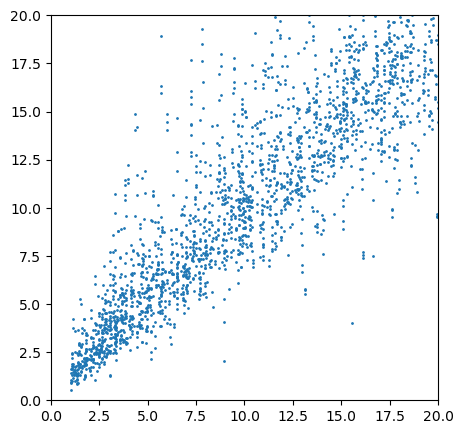

In [6]:
fig, axs = plt.subplots(figsize=(5, 5))

axs.scatter(df_enmap['emission_rate'], df_enmap['q_csf']/1e3, s=1)
axs.set_xlim(0, 20)
axs.set_ylim(0, 20)

In [10]:
def fit_data(x, y, fit_intercept):
    # ---- Density coloring ----
    xy = np.vstack([x, y])
    z = gaussian_kde(xy)(xy)
    
    idx = z.argsort()
    x, y, z = x[idx], y[idx], z[idx]
    
    # ---- Huber regression (through zero) ----
    X = x.reshape(-1, 1)

    model = HuberRegressor(fit_intercept=fit_intercept)
    model.fit(X, y)
    
    slope = model.coef_[0]
    y_fit = model.predict(X)
    intercept = model.intercept_
    
    # ---- R² (zero-intercept version) ----
    ss_res = np.sum((y - y_fit)**2)
    ss_tot = np.sum(y**2)
    r2 = 1 - ss_res / ss_tot

    return slope, intercept, r2

Text(0, 0.5, 'Estimation (t/h) using calibration')

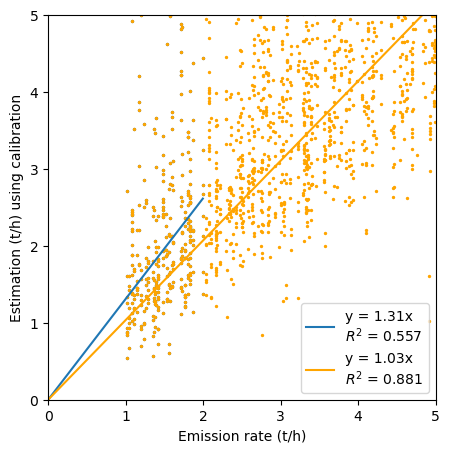

In [16]:
fig, axs = plt.subplots(figsize=(5, 5))

def plot_fit(df, ax, color='C0', estimate='q_csf', fit_intercept=False):
    x = df['emission_rate'].values
    y = df[estimate].values/1e3
    slope, intercept, r2 = fit_data(x, y, fit_intercept)
    ax.scatter(x, y, s=2, c=color)
    
    x_line = np.linspace(0, x.max(), 100)
    y_line = slope * x_line + intercept
    if intercept != 0:
        ax.plot(x_line, y_line, c=color,
                 label=f'y = {slope:.2f}x+{intercept.round(2)}\n$R^2$ = {r2:.3f}')
    else:
        ax.plot(x_line, y_line, c=color,
                 label=f'y = {slope:.2f}x\n$R^2$ = {r2:.3f}')

plot_fit(pd.concat([df_enmap_low, df_emit_low, df_prisma_low]), axs)
plot_fit(pd.concat([df_enmap, df_emit, df_prisma]), axs, color='orange')


plt.legend()

axs.set_xlim(0, 5)
axs.set_ylim(0, 5)
axs.set_xlabel('Emission rate (t/h)')
axs.set_ylabel('Estimation (t/h) using calibration')

Text(0, 0.5, 'Estimation (t/h) using calibration')

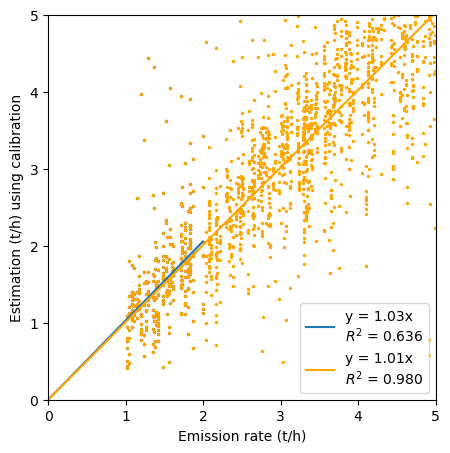

In [18]:
fig, axs = plt.subplots(figsize=(5, 5))

plot_fit(pd.concat([df_enmap_low, df_emit_low, df_prisma_low]), axs, estimate='q_ime', fit_intercept=False)
plot_fit(pd.concat([df_enmap, df_emit, df_prisma]), axs, color='orange', estimate='q_ime', fit_intercept=False)

plt.legend()

axs.set_xlim(0, 5)
axs.set_ylim(0, 5)
axs.set_xlabel('Emission rate (t/h)')
axs.set_ylabel('Estimation (t/h) using calibration')